# NVIDIA Nemotron Reasoning Challenge — Dataset Structure & Problem Families

> [![GitHub Repo](https://img.shields.io/badge/GitHub-morshoto%2Fkaggle--template--pacakge-181717?logo=github)](https://github.com/morshoto/kaggle-template-pacakge)
> 
> This notebook is built on top of [`morshoto/kaggle-template-pacakge`](https://github.com/morshoto/kaggle-template-pacakge), which provided the notebook structure and workflow scaffolding.

This notebook is written as an **EDA + problem-typing discussion** for the Kaggle competition **NVIDIA Nemotron Model Reasoning Challenge**. Rather than jumping straight into modeling, the goal here is to answer a simpler question first:

**What kinds of reasoning tasks are actually mixed into this dataset?**

Understanding that structure helps with:
- choosing validation strategies
- designing task-aware prompts or models
- deciding whether a single solver is enough, or whether a routing / ensemble approach makes more sense

## What this notebook shows

- basic dataset sanity checks
- answer-format distribution
- recurring prompt templates and keywords
- unsupervised clustering of prompt families
- practical takeaways for feature engineering and solution design

> **Main takeaway:** the training set is not one homogeneous reasoning task. It is a mixture of several highly templated sub-families with different answer formats (binary, numeric, Roman numerals, short text, symbolic mapping, etc.).

## 1. Environment / Reproducibility

This section only sets up imports, paths, and runtime configuration so the notebook can run both locally and on Kaggle.


In [1]:
# Standard library
import os
import json
import random
import subprocess
import warnings
import zipfile
from pathlib import Path

# Numerical / data
import numpy as np
import pandas as pd

# Machine learning / experiment tracking
import torch
import wandb
from scipy.stats import rankdata
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.model_selection import GroupKFold
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')


In [2]:
# Global config
global_params = dict(
    comp_slug       = "nvidia-nemotron-model-reasoning-challenge",
    target_col      = "",
    id_col          = "id",
    n_folds         = 5,
    random_state    = 42,
    kaggle_comp_dir = Path("/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge"),
    local_data_dir  = Path("data/raw"),
)

# Set all random seeds
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(global_params['random_state'])
np.random.seed(global_params['random_state'])
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(global_params['random_state'])
    torch.set_float32_matmul_precision('high')

global_params['local_data_dir'].mkdir(parents=True, exist_ok=True)
print(f"Device: {DEVICE}")


Device: cpu


## 3. Data Loading

Load the official competition files, then verify that the notebook is pointed at the expected train/test assets.


In [3]:
kaggle_dir = global_params['kaggle_comp_dir']
local_dir  = global_params['local_data_dir']

if kaggle_dir.exists():
    data_dir = kaggle_dir
    print("[Kaggle] Using mounted competition data:", data_dir)
else:
    data_dir = local_dir
    env.download_competition(local_dir)
    print("✅ Download completed. Using local data:", data_dir)


[Kaggle] Using mounted competition data: /kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge


In [4]:
def _read_csv(name: str) -> pd.DataFrame | None:
    path = data_dir / name
    if not path.exists():
        print(f"[skip] missing: {name}")
        return None
    df = pd.read_csv(path)
    print(f"[ok] {name}: {df.shape}")
    return df

# Men's
df_train  = _read_csv("train.csv")
df_test  = _read_csv("test.csv")


[ok] train.csv: (9500, 3)
[ok] test.csv: (3, 2)


In [5]:
df_train

,id,prompt,answer
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",10010111
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",01000011
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book
3,001b24c4,"In Alice's Wonderland, numbers are secretly co...",XXXVIII
4,001c63cb,"In Alice's Wonderland, secret encryption rules...",wizard creates secret
...,...,...,...
9495,ffce9e31,"In Alice's Wonderland, a secret bit manipulati...",01100110
9496,ffd5bada,"In Alice's Wonderland, a secret unit conversio...",32.45
9497,ffd89354,"In Alice's Wonderland, secret encryption rules...",student sees the curious mirror
9498,ffdfb678,"In Alice's Wonderland, secret encryption rules...",the curious mouse creates


### Why start with EDA?

For this competition, prompt text itself already contains strong structural signals:
- repeated story framing (`Alice's Wonderland`)
- repeated operator descriptions
- repeated answer formats
- repeated symbolic or numeric templates

That means a lot of performance may come from **recognizing task family first**, then solving or modeling accordingly.


## 4. EDA — What is in the dataset?

Before clustering anything, it helps to inspect the raw shapes, answer formats, and prompt templates.


In [6]:
display(df_train.head(3))
display(df_test.head(3))

print("train shape:", df_train.shape)
print("test shape :", df_test.shape)

print("\ntrain dtypes")
print(df_train.dtypes)
print("\ntest dtypes")
print(df_test.dtypes)

print("\nmissing values")
display(df_train.isna().sum().to_frame("train_missing"))
display(df_test.isna().sum().to_frame("test_missing"))

print("\nduplicates")
print("train duplicated id     :", df_train["id"].duplicated().sum())
print("train duplicated prompt  :", df_train["prompt"].duplicated().sum())
print("train duplicated answer  :", df_train["answer"].duplicated().sum())


,id,prompt,answer
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",10010111
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",01000011
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book


,id,prompt
0,00066667,"In Alice's Wonderland, a secret bit manipulati..."
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati..."
2,00189f6a,"In Alice's Wonderland, secret encryption rules..."


train shape: (9500, 3)
test shape : (3, 2)

train dtypes
id        object
prompt    object
answer    object
dtype: object

test dtypes
id        object
prompt    object
dtype: object

missing values


,train_missing
id,0
prompt,0
answer,0


,test_missing
id,0
prompt,0



duplicates
train duplicated id     : 0
train duplicated prompt  : 0
train duplicated answer  : 3579


,prompt_len_char,prompt_len_word,answer_len_char,answer_len_word
count,9500.000000,9500.000000,9500.000000,9500.000000
mean,301.515895,50.042947,8.393789,1.499474
std,104.265311,14.305601,8.035097,1.155232
min,177.000000,32.000000,1.000000,1.000000
25%,209.000000,36.000000,4.000000,1.000000
50%,281.000000,46.000000,5.000000,1.000000
75%,371.000000,65.000000,8.000000,1.000000
max,510.000000,78.000000,39.000000,5.000000


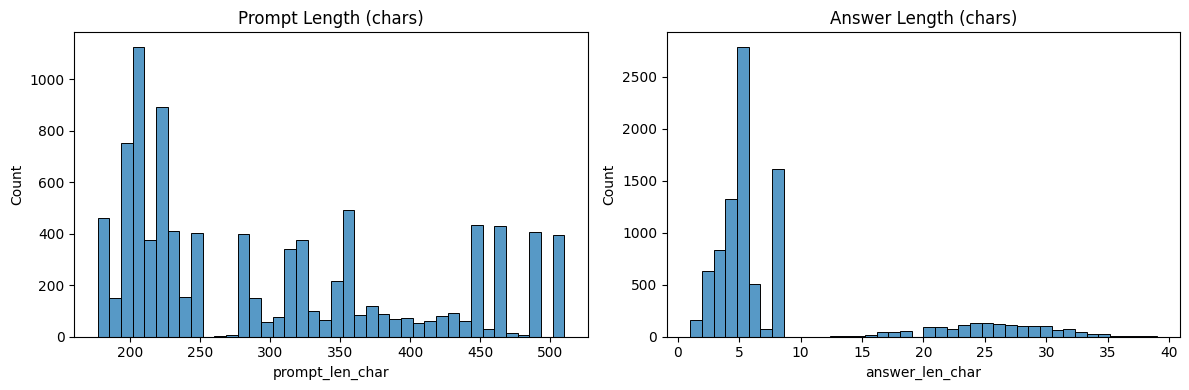

In [7]:
import seaborn as sns

eda = df_train.copy()
eda["prompt_len_char"] = eda["prompt"].str.len()
eda["prompt_len_word"] = eda["prompt"].str.split().str.len()
eda["answer_len_char"] = eda["answer"].astype(str).str.len()
eda["answer_len_word"] = eda["answer"].astype(str).str.split().str.len()

display(
    eda[["prompt_len_char", "prompt_len_word", "answer_len_char", "answer_len_word"]].describe()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(eda["prompt_len_char"], bins=40, ax=axes[0])
axes[0].set_title("Prompt Length (chars)")
sns.histplot(eda["answer_len_char"], bins=40, ax=axes[1])
axes[1].set_title("Answer Length (chars)")
plt.tight_layout()
plt.show()


,count
answer_type,
numeric,3846
binary,1634
english_phrase,1576
roman,1576
other,868


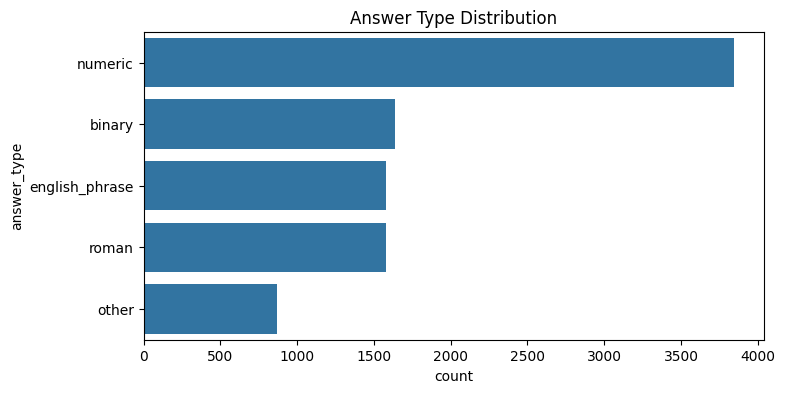

In [8]:
import re

def classify_answer(x: str) -> str:
    x = str(x).strip()
    if re.fullmatch(r"[01]+", x):
        return "binary"
    if re.fullmatch(r"-?\d+(\.\d+)?", x):
        return "numeric"
    if re.fullmatch(r"[IVXLCDM]+", x):
        return "roman"
    if re.fullmatch(r"[A-Za-z]+(?: [A-Za-z]+)*", x):
        return "english_phrase"
    return "other"

eda["answer_type"] = eda["answer"].astype(str).map(classify_answer)
display(eda["answer_type"].value_counts(dropna=False).to_frame("count"))

plt.figure(figsize=(8, 4))
sns.countplot(data=eda, y="answer_type", order=eda["answer_type"].value_counts().index)
plt.title("Answer Type Distribution")
plt.show()


In [9]:
keywords = ["bit", "binary", "roman", "encryption", "gravitational", "conversion", "Alice"]
keyword_counts = {
    keyword: df_train["prompt"].str.contains(keyword, case=False, na=False).sum()
    for keyword in keywords
}
display(pd.Series(keyword_counts, name="count").sort_values(ascending=False).to_frame())

df_train["prompt_prefix"] = df_train["prompt"].str[:80]
display(df_train["prompt_prefix"].value_counts().head(20).to_frame("count"))


,count
Alice,9500
bit,1988
binary,1602
gravitational,1597
conversion,1594
encryption,1576
roman,0


,count
prompt_prefix,
"In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary nu",1602
"In Alice's Wonderland, the gravitational constant has been secretly changed. Her",1597
"In Alice's Wonderland, a secret unit conversion is applied to measurements. For",1594
"In Alice's Wonderland, secret encryption rules are used on text. Here are some e",1576
"In Alice's Wonderland, numbers are secretly converted into a different numeral s",1576
"In Alice's Wonderland, a secret set of transformation rules is applied to equati",1555


### Clustering plan

The clustering workflow here is deliberately simple and interpretable:

- normalize prompt text
- build TF-IDF features
- reduce dimensionality with SVD
- cluster in the reduced space with KMeans
- inspect each cluster using top keywords, answer-type composition, and sampled prompts

This is not meant to be the final production pipeline. It is a way to discover whether the dataset naturally decomposes into clean subproblems.


## 5. Prompt Clustering — Recovering latent problem families

The prompts are heavily templated, so an unsupervised text pipeline should be able to separate hidden task types quite well.


In [10]:
import re
import numpy as np
import pandas as pd

cluster_df = df_train.copy()

def normalize_prompt(text: str) -> str:
    text = str(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text.strip())
    text = re.sub(r"\b\d+\b", " <NUM> ", text)
    text = re.sub(r"\b[0-9a-f]{8,}\b", " <HEX> ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cluster_df["prompt_norm"] = cluster_df["prompt"].astype(str).map(normalize_prompt)

cluster_df["prompt_len_char"] = cluster_df["prompt"].astype(str).str.len()
cluster_df["prompt_len_word"] = cluster_df["prompt"].astype(str).str.split().str.len()
cluster_df["n_newlines"] = cluster_df["prompt"].astype(str).str.count(r"\n")
cluster_df["has_arrow"] = cluster_df["prompt"].astype(str).str.contains(r"->|=>|→", regex=True, na=False).astype(int)
cluster_df["has_colon"] = cluster_df["prompt"].astype(str).str.contains(":", regex=False, na=False).astype(int)
cluster_df["has_digits"] = cluster_df["prompt"].astype(str).str.contains(r"\d", regex=True, na=False).astype(int)

display(cluster_df[["prompt", "prompt_norm"]].head(3))

,prompt,prompt_norm
0,"In Alice's Wonderland, a secret bit manipulati...","in alice's wonderland, a secret bit manipulati..."
1,"In Alice's Wonderland, a secret bit manipulati...","in alice's wonderland, a secret bit manipulati..."
2,"In Alice's Wonderland, secret encryption rules...","in alice's wonderland, secret encryption rules..."


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    strip_accents="unicode",
    sublinear_tf=True,
)

X_tfidf = tfidf.fit_transform(cluster_df["prompt_norm"])
print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (9500, 2200)


In [12]:
from sklearn.decomposition import TruncatedSVD

n_components = min(100, X_tfidf.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

print("SVD shape:", X_svd.shape)
print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum())

SVD shape: (9500, 100)
Explained variance ratio sum: 0.7379374106567694


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = cluster_df.copy()

try:
    import umap

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.15,
        metric="cosine",
        random_state=42,
    )
    X_2d = reducer.fit_transform(X_svd)
    method_name = "UMAP"
except Exception:
    from sklearn.decomposition import PCA
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X_svd)
    method_name = "PCA"

plot_df["x"] = X_2d[:, 0]
plot_df["y"] = X_2d[:, 1]

2026-03-19 00:10:44.595159: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773879044.883055      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773879044.968166      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773879045.718610      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773879045.718655      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773879045.718659      17 computation_placer.cc:177] computation placer alr

In [14]:
from sklearn.cluster import KMeans

N_CLUSTERS = 10

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=20,
)
cluster_df["problem_family"] = kmeans.fit_predict(X_svd)

display(cluster_df["problem_family"].value_counts().sort_index().to_frame("count"))

,count
problem_family,
0,345
1,1602
2,1594
3,823
4,1597
5,764
6,220
7,732
8,812


In [15]:
terms = np.array(tfidf.get_feature_names_out())
centers_svd = kmeans.cluster_centers_
centers_tfidf_approx = svd.inverse_transform(centers_svd)

top_k = 12
cluster_keywords = {}

for i, row in enumerate(centers_tfidf_approx):
    top_idx = np.argsort(row)[::-1][:top_k]
    cluster_keywords[i] = ", ".join(terms[top_idx])

cluster_keyword_df = pd.DataFrame({
    "problem_family": list(cluster_keywords.keys()),
    "top_keywords": list(cluster_keywords.values()),
}).sort_values("problem_family")

display(cluster_keyword_df)

,problem_family,top_keywords
0,0,"text, encryption, secret encryption, used, fol..."
1,1,"bit, num num, num, and, output, or, manipulati..."
2,2,"becomes num, becomes, num becomes, num num, nu..."
3,3,"examples now, rules is, result, are few, set, ..."
4,4,"distance, distance num, num for, for num, num,..."
5,5,"numeral, numeral system, system, num, in the, ..."
6,6,"text, the wise, wise, encryption, now decrypt,..."
7,7,"num num, num, examples num, secret set, the re..."
8,8,"numeral system, numeral, system, num, are give..."
9,9,"text, encryption rules, are used, decrypt the,..."


In [16]:
def show_cluster_samples(df, cluster_col="problem_family", text_col="prompt", n=5, text_len=220):
    for c in sorted(df[cluster_col].unique()):
        print("=" * 100)
        print(f"CLUSTER {c}")
        kw = cluster_keyword_df.loc[cluster_keyword_df["problem_family"] == c, "top_keywords"].iloc[0]
        print("keywords:", kw)
        print("-" * 100)
        
        sample_rows = df[df[cluster_col] == c].sample(min(n, (df[cluster_col] == c).sum()), random_state=42)
        for _, row in sample_rows.iterrows():
            text = str(row[text_col]).replace("\n", " ")
            print(f"[id={row['id']}] {text[:text_len]}...")
            if "answer" in row:
                print(f"answer: {row['answer']}")
            print()

show_cluster_samples(cluster_df, n=5)

CLUSTER 0
keywords: text, encryption, secret encryption, used, following text, are used, rules are, on text, on, used on, encryption rules, text here
----------------------------------------------------------------------------------------------------
[id=94d5d7dd] In Alice's Wonderland, secret encryption rules are used on text. Here are some examples: lsj uajwjt ljousjt rlbkejr -> the clever teacher studies oaeuj efoxezjr knnt -> alice imagines door lsj unanthba ctezujrr efoxezjr ...
answer: dragon follows book

[id=79c84e68] In Alice's Wonderland, secret encryption rules are used on text. Here are some examples: qhl gnccnbw vtonak wqjnnc -> cat follows beyond school ljt wluhart iudaqtww wlykdtw -> the strange princess studies qhl dehrdatw lj...
answer: mouse sees the magical crystal

[id=aad72504] In Alice's Wonderland, secret encryption rules are used on text. Here are some examples: gwcgvd cdbrk bciwjr xbad -> turtle reads around cave sqcr rcbnk xbkgvd -> bird draws castle ged rbct 

### First strong signal

At this point the pattern becomes quite clear: most clusters align almost perfectly with a specific answer format or transformation style.

That is useful because it suggests the competition may reward **specialization** more than a one-size-fits-all reasoning strategy.


In [17]:
cluster_df = cluster_df.merge(
    eda[[global_params["id_col"], "answer_type"]],
    on=global_params["id_col"],
    how="left"
)

cross_tab = pd.crosstab(cluster_df["problem_family"], cluster_df["answer_type"])
display(cross_tab)

cross_tab_ratio = pd.crosstab(
    cluster_df["problem_family"],
    cluster_df["answer_type"],
    normalize="index"
).round(3)

display(cross_tab_ratio.style.background_gradient(cmap="Blues"))

answer_type,binary,english_phrase,numeric,other,roman
problem_family,,,,,
0,0,345,0,0,0
1,1602,0,0,0,0
2,0,0,1594,0,0
3,0,0,0,823,0
4,0,0,1597,0,0
5,0,0,0,0,764
6,0,220,0,0,0
7,32,0,655,45,0
8,0,0,0,0,812


answer_type,binary,english_phrase,numeric,other,roman
problem_family,,,,,
0,0.000000,1.000000,0.000000,0.000000,0.000000
1,1.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,1.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,1.000000,0.000000
4,0.000000,0.000000,1.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,1.000000
6,0.000000,1.000000,0.000000,0.000000,0.000000
7,0.044000,0.000000,0.895000,0.061000,0.000000
8,0.000000,0.000000,0.000000,0.000000,1.000000


In [18]:
family_stats = (
    cluster_df
    .groupby("problem_family")
    .agg(
        n_samples=("id", "count"),
        prompt_len_char_mean=("prompt_len_char", "mean"),
        prompt_len_word_mean=("prompt_len_word", "mean"),
        n_newlines_mean=("n_newlines", "mean"),
        has_arrow_rate=("has_arrow", "mean"),
        has_colon_rate=("has_colon", "mean"),
        has_digits_rate=("has_digits", "mean"),
    )
    .sort_values("n_samples", ascending=False)
    .round(3)
)

display(family_stats)

,n_samples,prompt_len_char_mean,prompt_len_word_mean,n_newlines_mean,has_arrow_rate,has_colon_rate,has_digits_rate
problem_family,,,,,,,
1,1602,478.566,69.509,12.503,1.000,1.0,1.0
4,1597,320.262,60.396,5.049,0.000,1.0,1.0
2,1594,222.240,35.932,4.983,0.000,1.0,1.0
9,1011,365.945,57.940,4.929,1.000,1.0,0.0
3,823,195.604,36.182,5.061,0.063,1.0,0.0
8,812,218.564,38.693,4.898,1.000,1.0,1.0
5,764,219.728,39.004,5.001,1.000,1.0,1.0
7,732,194.615,35.955,4.985,0.000,1.0,1.0
0,345,378.559,60.774,5.130,1.000,1.0,0.0


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = cluster_df.copy()

try:
    import umap

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.15,
        metric="cosine",
        random_state=42,
    )
    X_2d = reducer.fit_transform(X_svd)
    method_name = "UMAP"
except Exception:
    from sklearn.decomposition import PCA
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X_svd)
    method_name = "PCA"

plot_df["x"] = X_2d[:, 0]
plot_df["y"] = X_2d[:, 1]

In [20]:
family_name_map = {
    0: "numeric-rule",
    1: "binary-transform",
    2: "roman-numeral",
    3: "mapping-symbolic",
    4: "sequence-rule",
    5: "string-transform",
    6: "logic-short-answer",
    7: "encoding-decoding",
    8: "table-like-rule",
    9: "mixed-template",
}

plot_df["family_name"] = plot_df["problem_family"].map(
    lambda x: family_name_map.get(x, f"family_{x}")
)

### Visual check

The 2D projection is only a visualization, so exact distances should not be over-interpreted.  
Still, if the families separate cleanly in UMAP space, that is a good sanity check that the TF-IDF/SVD representation is capturing real task structure rather than noise.


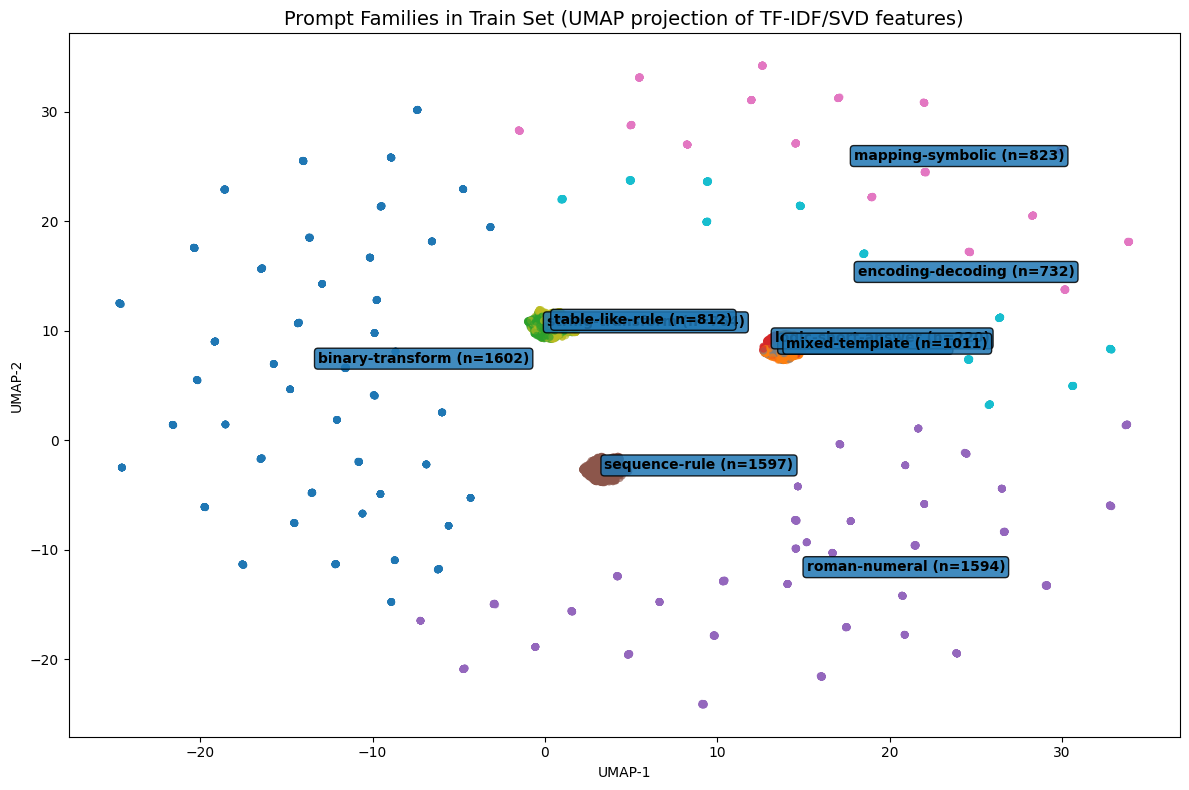

In [21]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_df,
    x="x",
    y="y",
    hue="family_name",
    s=28,
    alpha=0.65,
    linewidth=0,
)

centers_2d = (
    plot_df.groupby(["problem_family", "family_name"])[["x", "y"]]
    .mean()
    .reset_index()
)

counts = plot_df["problem_family"].value_counts().to_dict()

for _, row in centers_2d.iterrows():
    c = row["problem_family"]
    label = f"{row['family_name']} (n={counts[c]})"
    plt.text(
        row["x"],
        row["y"],
        label,
        fontsize=10,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.85),
    )

plt.title(f"Prompt Families in Train Set ({method_name} projection of TF-IDF/SVD features)", fontsize=14)
plt.xlabel(f"{method_name}-1")
plt.ylabel(f"{method_name}-2")
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

In [22]:
family_summary = (
    cluster_df
    .groupby("problem_family")
    .agg(
        n_samples=("id", "count"),
        prompt_len_char_mean=("prompt_len_char", "mean"),
        prompt_len_word_mean=("prompt_len_word", "mean"),
        n_newlines_mean=("n_newlines", "mean"),
        has_arrow_rate=("has_arrow", "mean"),
        has_colon_rate=("has_colon", "mean"),
        has_digits_rate=("has_digits", "mean"),
    )
    .reset_index()
)

family_summary["family_name"] = family_summary["problem_family"].map(
    lambda x: family_name_map.get(x, f"family_{x}")
)

family_summary = family_summary.merge(
    cluster_keyword_df,
    on="problem_family",
    how="left"
)

family_summary = family_summary.sort_values("n_samples", ascending=False).round(3)
display(family_summary)

,problem_family,n_samples,prompt_len_char_mean,prompt_len_word_mean,n_newlines_mean,has_arrow_rate,has_colon_rate,has_digits_rate,family_name,top_keywords
1,1,1602,478.566,69.509,12.503,1.000,1.0,1.0,binary-transform,"bit, num num, num, and, output, or, manipulati..."
4,4,1597,320.262,60.396,5.049,0.000,1.0,1.0,sequence-rule,"distance, distance num, num for, for num, num,..."
2,2,1594,222.240,35.932,4.983,0.000,1.0,1.0,roman-numeral,"becomes num, becomes, num becomes, num num, nu..."
9,9,1011,365.945,57.940,4.929,1.000,1.0,0.0,mixed-template,"text, encryption rules, are used, decrypt the,..."
3,3,823,195.604,36.182,5.061,0.063,1.0,0.0,mapping-symbolic,"examples now, rules is, result, are few, set, ..."
8,8,812,218.564,38.693,4.898,1.000,1.0,1.0,table-like-rule,"numeral system, numeral, system, num, are give..."
5,5,764,219.728,39.004,5.001,1.000,1.0,1.0,string-transform,"numeral, numeral system, system, num, in the, ..."
7,7,732,194.615,35.955,4.985,0.000,1.0,1.0,encoding-decoding,"num num, num, examples num, secret set, the re..."
0,0,345,378.559,60.774,5.130,1.000,1.0,0.0,numeric-rule,"text, encryption, secret encryption, used, fol..."
6,6,220,375.777,61.214,5.123,1.000,1.0,0.0,logic-short-answer,"text, the wise, wise, encryption, now decrypt,..."


In [23]:
def get_cluster_examples(df, cluster_id, n=3, text_len=180):
    tmp = df[df["problem_family"] == cluster_id].copy()
    tmp = tmp.sample(min(n, len(tmp)), random_state=42)
    rows = []
    for _, r in tmp.iterrows():
        rows.append({
            "problem_family": cluster_id,
            "family_name": family_name_map.get(cluster_id, f"family_{cluster_id}"),
            "id": r["id"],
            "prompt_excerpt": str(r["prompt"]).replace("\n", " ")[:text_len] + "...",
            "answer": r.get("answer", None),
        })
    return pd.DataFrame(rows)

example_df = pd.concat(
    [get_cluster_examples(cluster_df, c, n=3) for c in sorted(cluster_df["problem_family"].unique())],
    ignore_index=True
)

display(example_df)

,problem_family,family_name,id,prompt_excerpt,answer
0,0,numeric-rule,94d5d7dd,"In Alice's Wonderland, secret encryption rules...",dragon follows book
1,0,numeric-rule,79c84e68,"In Alice's Wonderland, secret encryption rules...",mouse sees the magical crystal
2,0,numeric-rule,aad72504,"In Alice's Wonderland, secret encryption rules...",king discovers the clever castle
3,1,binary-transform,54d2b3b0,"In Alice's Wonderland, a secret bit manipulati...",00000000
4,1,binary-transform,b80795b4,"In Alice's Wonderland, a secret bit manipulati...",00010000
5,1,binary-transform,18ab3864,"In Alice's Wonderland, a secret bit manipulati...",10100000
6,2,roman-numeral,94934452,"In Alice's Wonderland, a secret unit conversio...",53.82
7,2,roman-numeral,b2e7ee08,"In Alice's Wonderland, a secret unit conversio...",33.02
8,2,roman-numeral,cc6a45f8,"In Alice's Wonderland, a secret unit conversio...",27.94
9,3,mapping-symbolic,bcff7dbe,"In Alice's Wonderland, a secret set of transfo...",>[


## Discussion takeaways

**The dataset is highly structured**
The competition looks like a single reasoning benchmark on the surface, but the prompts break into several recurring templates with distinct output spaces.

**Output format matters a lot**
Binary strings, Roman numerals, numeric answers, symbolic mappings, and short English phrases behave like different tasks. Even a strong general model may benefit from format-aware handling.

**Routing is a plausible strategy**
A lightweight classifier or rule-based router could first predict the problem family, then dispatch to a specialized solver, prompt template, or decoding constraint.

**Validation should respect family balance**
If folds are accidentally imbalanced across families, local validation may become misleading. Family-aware CV or at least family diagnostics are worth checking.

**This notebook is a starting point, not the final answer**
The clustering here is intentionally simple. The next step would be to turn these discovered families into actual modeling gains:
- family-conditioned prompts
- family-specific post-processing
- constrained decoding by answer type
- mixture-of-experts or router-based ensembling

## Final thought

My main conclusion is that **understanding the dataset taxonomy is itself a competitive advantage** in this challenge.  
Before optimizing models, it is worth spending time on task decomposition, because the benchmark appears to be a mixture of several narrow reasoning games rather than one uniform task.
